In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, BatchNormalization 
import seaborn as sns
from sklearn.datasets import make_circles

In [ ]:
# Set style for beautiful plots 
pit.style.use('seaborn-v0_8-darkgrid') 
sns.set_palette("husl")

In [ ]:
# Load and explore data 
X, y = make_circles(
    n_samples=1000,
    noise=0.2,
    factor=0.5,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)


In [ ]:
# 2. Create DataFrame
# ==========================================

df = pd.DataFrame(X, columns=['X', 'Y'])

df['class'] = y

print(df.head())

In [ ]:
# 3. Visualize the dataset
# ==========================================

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Original data visualization
ax[0].scatter(
    df['X'],
    df['Y'],
    c=df['class'],
    cmap='viridis',
    alpha=0.6
)

ax[0].set_title(
    'Concentric Circles Dataset',
    fontsize=14
)

ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')


# ==========================================

In [44]:
# 4. Class distribution
# ==========================================

df['class'].value_counts().plot(
    kind='bar',
    ax=ax[1]
)

ax[1].set_title(
    'Class Distribution',
    fontsize=14
)

ax[1].set_xlabel('Class')
ax[1].set_ylabel('Count')


plt.tight_layout()
plt.show()


# ==========================================

<Figure size 640x480 with 0 Axes>

In [45]:
# 5. Prepare data for ML
# ==========================================

X = df.iloc[:, 0:2].values
y = df.iloc[:, -1].values


print("\nData shapes:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


Data shapes:
X shape: (1000, 2)
y shape: (1000,)


In [46]:
# Model 1: Without Batch Normalization

print("\nBuilding Model WITHOUT Batch Normalization...")

model_without_bn = Sequential([
    
    Dense(
        3,
        activation='relu',
        input_dim=2,
        name='hidden1'
    ),
    
    Dense(
        2,
        activation='relu',
        name='hidden2'
    ),
    
    Dense(
        1,
        activation='sigmoid',
        name='output'
    )
])


# Compile the model
model_without_bn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# Model summary
print("Model 1 Summary:")
model_without_bn.summary()


Building Model WITHOUT Batch Normalization...
Model 1 Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-09-19 14:43:46.878123: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
# Model 2: With Batch Normalization

print("\nBuilding Model WITH Batch Normalization...")

model_with_bn = Sequential([
    
    Dense(
        3,
        activation='relu',
        input_dim=2,
        name='hidden1_bn'
    ),
    
    BatchNormalization(
        name='bn1'
    ),
    
    Dense(
        2,
        activation='relu',
        name='hidden2_bn'
    ),
    
    BatchNormalization(
        name='bn2'
    ),
    
    Dense(
        1,
        activation='sigmoid',
        name='output_bn'
    )
])


# Compile the model
model_with_bn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


# Model summary
print("Model 2 Summary:")
model_with_bn.summary()


Building Model WITH Batch Normalization...
Model 2 Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1_bn (Dense)              │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2_bn (Dense)              │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_bn (Dense)               │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 30 (120.00 B)

 Non-trainable params: 10 (40.00 B)

In [48]:
# Parameter Analysis
# ==========================================

def analyze_bn_params(model):
    """Analyze BatchNormalization parameters"""

    print("\nBatch Normalization Parameter Analysis:")

    for layer in model.layers:

        if isinstance(layer, BatchNormalization):

            print(f"\nLayer: {layer.name}")

            print(
                f"Total parameters: {layer.count_params()}"
            )

            print(
                f"Trainable parameters: "
                f"{sum(w.shape.num_elements() for w in layer.trainable_weights)}"
            )

            print(
                f"Non-trainable parameters: "
                f"{sum(w.shape.num_elements() for w in layer.non_trainable_weights)}"
            )


analyze_bn_params(model_with_bn)


Batch Normalization Parameter Analysis:

Layer: bn1
Total parameters: 12
Trainable parameters: 6
Non-trainable parameters: 6

Layer: bn2
Total parameters: 8
Trainable parameters: 4
Non-trainable parameters: 4


In [49]:
# Train both models
# ==========================================

print("\nTraining models...")

history1 = model_without_bn.fit(
    X,
    y,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

history2 = model_with_bn.fit(
    X,
    y,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)


# ==========================================


Training models...


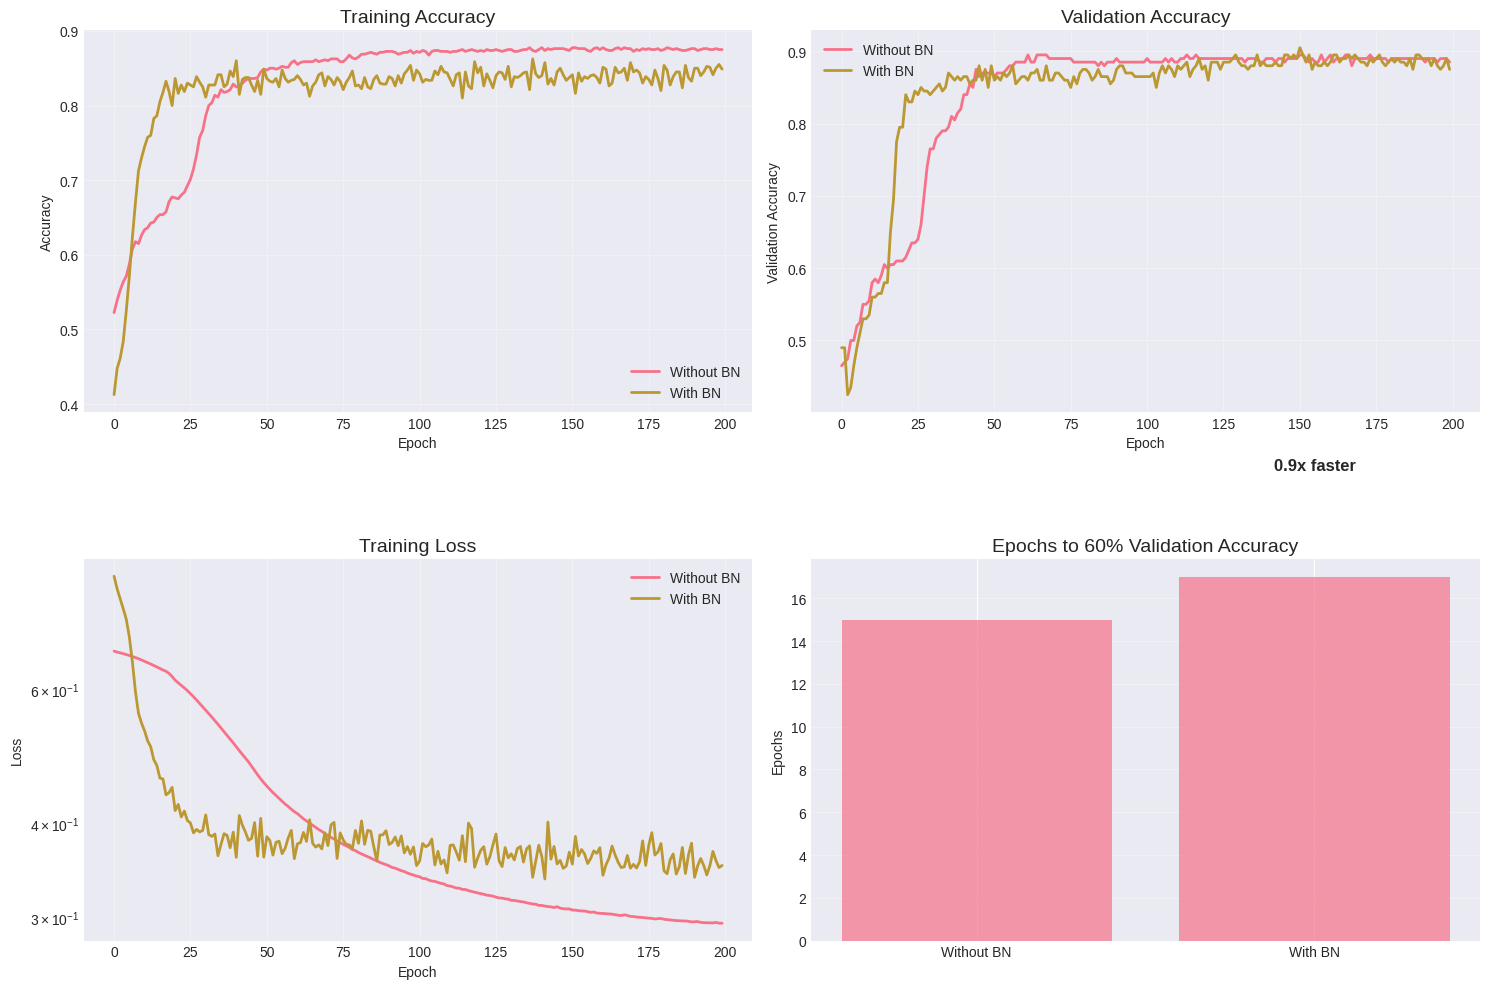


Performance Summary:
Metric                        Without BN     With BN        
Final Validation Accuracy     0.8850         0.8750         
Epochs to 60% accuracy        15             17             
Speedup factor                1.0x           0.88           x
Best Validation Accuracy      0.8950         0.9050         

Visualizing Batch Normalization Parameters...


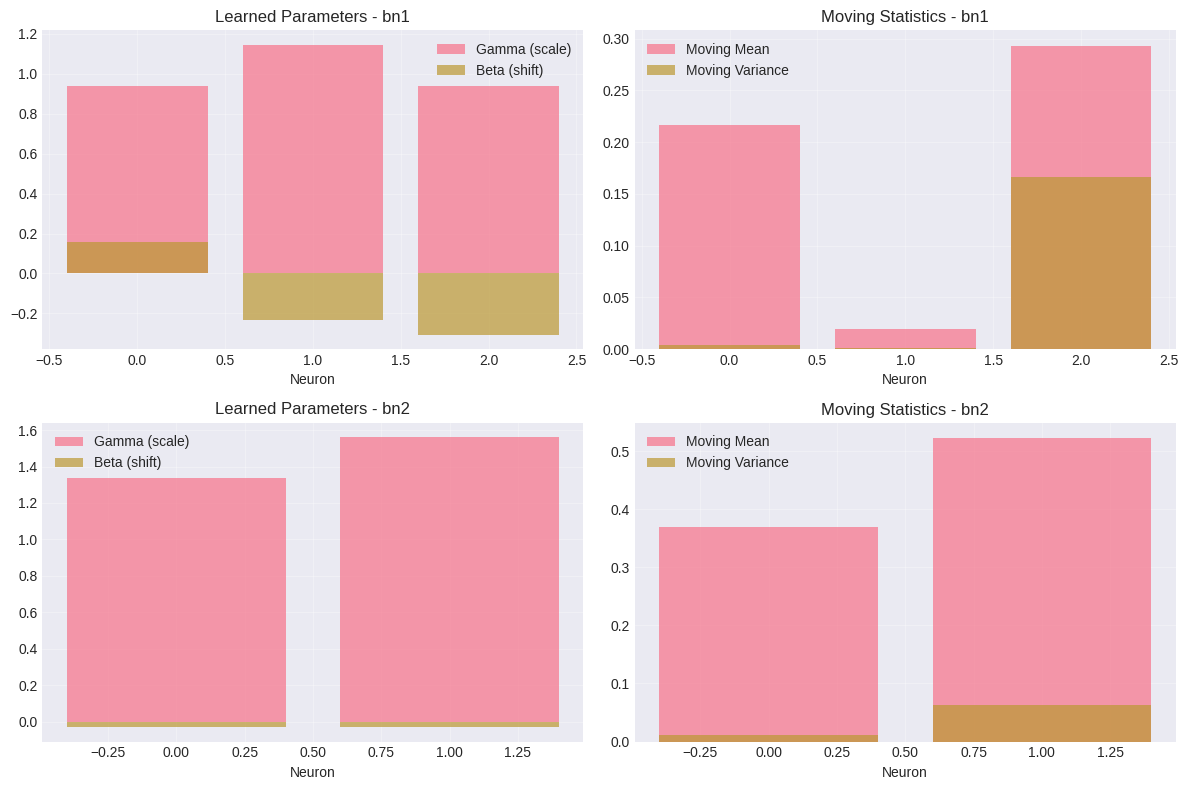

In [58]:
# ==========================================
# Comprehensive Visualization
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)


# ------------------------------------------
# 1. Training Accuracy
# ------------------------------------------

axes[0, 0].plot(
    history1.history['accuracy'],
    label='Without BN',
    linewidth=2
)

axes[0, 0].plot(
    history2.history['accuracy'],
    label='With BN',
    linewidth=2
)

axes[0, 0].set_title(
    'Training Accuracy',
    fontsize=14
)

axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')

axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)


# ------------------------------------------
# 2. Validation Accuracy
# ------------------------------------------

axes[0, 1].plot(
    history1.history['val_accuracy'],
    label='Without BN',
    linewidth=2
)

axes[0, 1].plot(
    history2.history['val_accuracy'],
    label='With BN',
    linewidth=2
)

axes[0, 1].set_title(
    'Validation Accuracy',
    fontsize=14
)

axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Accuracy')

axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)


# ------------------------------------------
# 3. Training Loss
# ------------------------------------------

axes[1, 0].plot(
    history1.history['loss'],
    label='Without BN',
    linewidth=2
)

axes[1, 0].plot(
    history2.history['loss'],
    label='With BN',
    linewidth=2
)

axes[1, 0].set_title(
    'Training Loss',
    fontsize=14
)

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')

axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Log scale
axes[1, 0].set_yscale('log')


# ==========================================
# Convergence Speed Analysis
# ==========================================

def find_convergence_epoch(history, threshold=0.6):
    """Find epoch where validation accuracy first exceeds threshold"""

    accuracies = history.history['val_accuracy']

    for i, acc in enumerate(accuracies):

        if acc >= threshold:
            return i + 1

    return len(accuracies)


conv_without = find_convergence_epoch(
    history1,
    0.6
)

conv_with = find_convergence_epoch(
    history2,
    0.6
)


# ------------------------------------------
# 4. Convergence Speed
# ------------------------------------------

axes[1, 1].bar(
    ['Without BN', 'With BN'],
    [conv_without, conv_with],
    alpha=0.7
)

axes[1, 1].set_title(
    'Epochs to 60% Validation Accuracy',
    fontsize=14
)

axes[1, 1].set_ylabel('Epochs')

axes[1, 1].grid(
    True,
    alpha=0.3,
    axis='y'
)


# Speedup calculation
if conv_with > 0:
    speedup = conv_without / conv_with
else:
    speedup = float('inf')


# Add annotation
axes[1, 1].text(
    1,
    conv_with + 5,
    f'{speedup:.1f}x faster',
    ha='center',
    fontsize=12,
    weight='bold'
)


plt.tight_layout()
plt.show()


# ==========================================
# Performance Metrics Summary
# ==========================================

print("\nPerformance Summary:")
print("=" * 65)

print(
    f"{'Metric':<30}"
    f"{'Without BN':<15}"
    f"{'With BN':<15}"
)

print("=" * 65)


final_acc_without = history1.history['val_accuracy'][-1]
final_acc_with = history2.history['val_accuracy'][-1]

best_acc_without = max(
    history1.history['val_accuracy']
)

best_acc_with = max(
    history2.history['val_accuracy']
)


print(
    f"{'Final Validation Accuracy':<30}"
    f"{final_acc_without:<15.4f}"
    f"{final_acc_with:<15.4f}"
)

print(
    f"{'Epochs to 60% accuracy':<30}"
    f"{conv_without:<15}"
    f"{conv_with:<15}"
)

print(
    f"{'Speedup factor':<30}"
    f"{'1.0x':<15}"
    f"{speedup:<15.2f}x"
)

print(
    f"{'Best Validation Accuracy':<30}"
    f"{best_acc_without:<15.4f}"
    f"{best_acc_with:<15.4f}"
)

print("=" * 65)


# ==========================================
# Visualize Learned BN Parameters
# ==========================================

def visualize_bn_params(model):
    """Visualize BatchNormalization parameters"""

    # Find all BatchNormalization layers
    bn_layers = [
        layer
        for layer in model.layers
        if isinstance(layer, BatchNormalization)
    ]

    fig, axes = plt.subplots(
        len(bn_layers),
        2,
        figsize=(12, 4 * len(bn_layers))
    )

    # Handle case of only one BN layer
    if len(bn_layers) == 1:
        axes = np.expand_dims(axes, axis=0)


    for idx, bn_layer in enumerate(bn_layers):

        # Get parameters
        gamma = bn_layer.get_weights()[0]
        beta = bn_layer.get_weights()[1]

        moving_mean = bn_layer.get_weights()[2]
        moving_var = bn_layer.get_weights()[3]


        # ----------------------------------
        # Gamma and Beta
        # ----------------------------------

        x = np.arange(len(gamma))

        axes[idx, 0].bar(
            x,
            gamma,
            alpha=0.7,
            label='Gamma (scale)'
        )

        axes[idx, 0].bar(
            x,
            beta,
            alpha=0.7,
            label='Beta (shift)'
        )

        axes[idx, 0].set_title(
            f'Learned Parameters - {bn_layer.name}'
        )

        axes[idx, 0].set_xlabel('Neuron')

        axes[idx, 0].legend()

        axes[idx, 0].grid(
            True,
            alpha=0.3
        )


        # ----------------------------------
        # Moving Mean and Variance
        # ----------------------------------

        axes[idx, 1].bar(
            x,
            moving_mean,
            alpha=0.7,
            label='Moving Mean'
        )

        axes[idx, 1].bar(
            x,
            moving_var,
            alpha=0.7,
            label='Moving Variance'
        )

        axes[idx, 1].set_title(
            f'Moving Statistics - {bn_layer.name}'
        )

        axes[idx, 1].set_xlabel('Neuron')

        axes[idx, 1].legend()

        axes[idx, 1].grid(
            True,
            alpha=0.3
        )


    plt.tight_layout()
    plt.show()


print("\nVisualizing Batch Normalization Parameters...")

visualize_bn_params(model_with_bn)

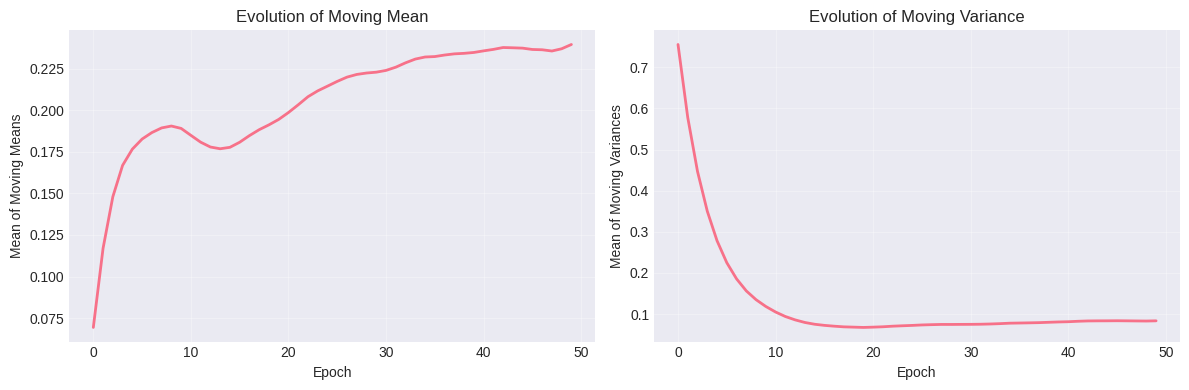

In [59]:
# ==========================================
# Advanced Implementation Features
# Custom Batch Normalization Callback
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import keras

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization


# ==========================================
# Custom Batch Normalization Monitor
# ==========================================

class BNMonitor(keras.callbacks.Callback):
    """Monitor BatchNormalization statistics during training"""

    def __init__(self):
        super().__init__()

        self.batch_means = []
        self.batch_vars = []


    def on_epoch_end(self, epoch, logs=None):
        """Collect BN statistics after every epoch"""

        epoch_means = []
        epoch_vars = []

        for layer in self.model.layers:

            if isinstance(layer, BatchNormalization):

                weights = layer.get_weights()

                # weights:
                # [0] = gamma
                # [1] = beta
                # [2] = moving_mean
                # [3] = moving_variance

                epoch_means.append(
                    weights[2].mean()
                )

                epoch_vars.append(
                    weights[3].mean()
                )

        # Average statistics across all BN layers
        if epoch_means:
            self.batch_means.append(
                np.mean(epoch_means)
            )

            self.batch_vars.append(
                np.mean(epoch_vars)
            )


    def plot_statistics(self):
        """Plot the evolution of BN statistics"""

        fig, (ax1, ax2) = plt.subplots(
            1,
            2,
            figsize=(12, 4)
        )


        # ----------------------------------
        # Moving Mean
        # ----------------------------------

        ax1.plot(
            self.batch_means,
            linewidth=2
        )

        ax1.set_title(
            'Evolution of Moving Mean'
        )

        ax1.set_xlabel('Epoch')

        ax1.set_ylabel(
            'Mean of Moving Means'
        )

        ax1.grid(
            True,
            alpha=0.3
        )


        # ----------------------------------
        # Moving Variance
        # ----------------------------------

        ax2.plot(
            self.batch_vars,
            linewidth=2
        )

        ax2.set_title(
            'Evolution of Moving Variance'
        )

        ax2.set_xlabel('Epoch')

        ax2.set_ylabel(
            'Mean of Moving Variances'
        )

        ax2.grid(
            True,
            alpha=0.3
        )


        plt.tight_layout()
        plt.show()


# ==========================================
# Train with Monitoring
# ==========================================

bn_monitor = BNMonitor()


model_monitored = Sequential([
    
    Dense(
        3,
        activation='relu',
        input_dim=2
    ),
    
    BatchNormalization(),
    
    Dense(
        2,
        activation='relu'
    ),
    
    BatchNormalization(),
    
    Dense(
        1,
        activation='sigmoid'
    )
])


# ==========================================
# Compile Model
# ==========================================

model_monitored.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ==========================================
# Train Model
# ==========================================

model_monitored.fit(
    X,
    y,
    epochs=50,
    batch_size=32,
    callbacks=[bn_monitor],
    verbose=0
)


# ==========================================
# Plot BN Statistics
# ==========================================

bn_monitor.plot_statistics()